# Working with Time-Series Data in pandas


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Udacity brand colors
UB = {
    "Brand Blue": "#175CFF", "Medium Blue": "#7BA2FF", "Light Blue": "#D2DFFF", "Navy": "#031643"
}
UN = {
    "Black": "#0A0B0F", "Dark Gray": "#5A5C62",
    "Medium Gray": "#9C9FA8", "Gray": "#CECFD4",
    "Light Gray": "#F2F2F2", "White": "#FFFFFF"
}
US = {
    "Orange": "#EE7622", "Yellow": "#F9DC5C",
    "Red": "#9C0D22", "Green": "#23CE6B"
}

mpl.rcParams["lines.linewidth"] = 3
mpl.rcParams["axes.linewidth"] = 2


## Loading and Parsing Dates


In [3]:
# Without parse_dates -- pandas treats the date column as a plain string
df_raw = pd.read_csv("../data/bikeshare_rides.csv")
print(f"date column type: {df_raw['date'].dtype}")
print(f"Index type: {type(df_raw.index)}")
df_raw.head()

date column type: object
Index type: <class 'pandas.core.indexes.range.RangeIndex'>


,date,rides
0,2022-01-01,2982
1,2022-01-02,2509
2,2022-01-03,2420
3,2022-01-04,2058
4,2022-01-05,2159


## Checking for Gaps


In [4]:
df = pd.read_csv("../data/bikeshare_rides.csv", parse_dates=["date"])
df = df.set_index("date")
print(f"Index type: {type(df.index)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Rows: {len(df)}")
df.head()

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date range: 2022-01-01 to 2024-12-31
Rows: 1094


,rides
date,
2022-01-01,2982
2022-01-02,2509
2022-01-03,2420
2022-01-04,2058
2022-01-05,2159


## Resampling


In [5]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing = full_range.difference(df.index)
dupes = df.index[df.index.duplicated()].unique()

print(f"Expected:   {len(full_range)} days")
print(f"Actual:     {len(df)} rows")
print(f"Missing:    {len(missing)} dates")
print(f"Duplicates: {len(dupes)} dates ({df.index.duplicated().sum()} extra rows)")
print(f"Net:        {len(full_range)} - {len(missing)} + {df.index.duplicated().sum()} = {len(df)}")

for d in missing[:3]:
    print(f"Missing    {d.date()}")
for d in dupes:
    print(f"Duplicate  {d.date()}")

Expected:   1096 days
Actual:     1094 rows
Missing:    5 dates
Duplicates: 3 dates (3 extra rows)
Net:        1096 - 5 + 3 = 1094
Missing    2023-02-10
Missing    2023-02-11
Missing    2023-02-12
Duplicate  2023-08-01
Duplicate  2023-08-02
Duplicate  2023-08-03


## Plotting at Different Frequencies


In [6]:
df = df[~df.index.duplicated(keep="first")]
print(f"After dedup: {len(df)} rows")

After dedup: 1091 rows


In [7]:
weekly = df["rides"].resample("W").sum()
monthly = df["rides"].resample("MS").sum()

print(f"Daily:   {len(df)} rows")
print(f"Weekly:  {len(weekly)} rows")
print(f"Monthly: {len(monthly)} rows")

Daily:   1091 rows
Weekly:  158 rows
Monthly: 36 rows


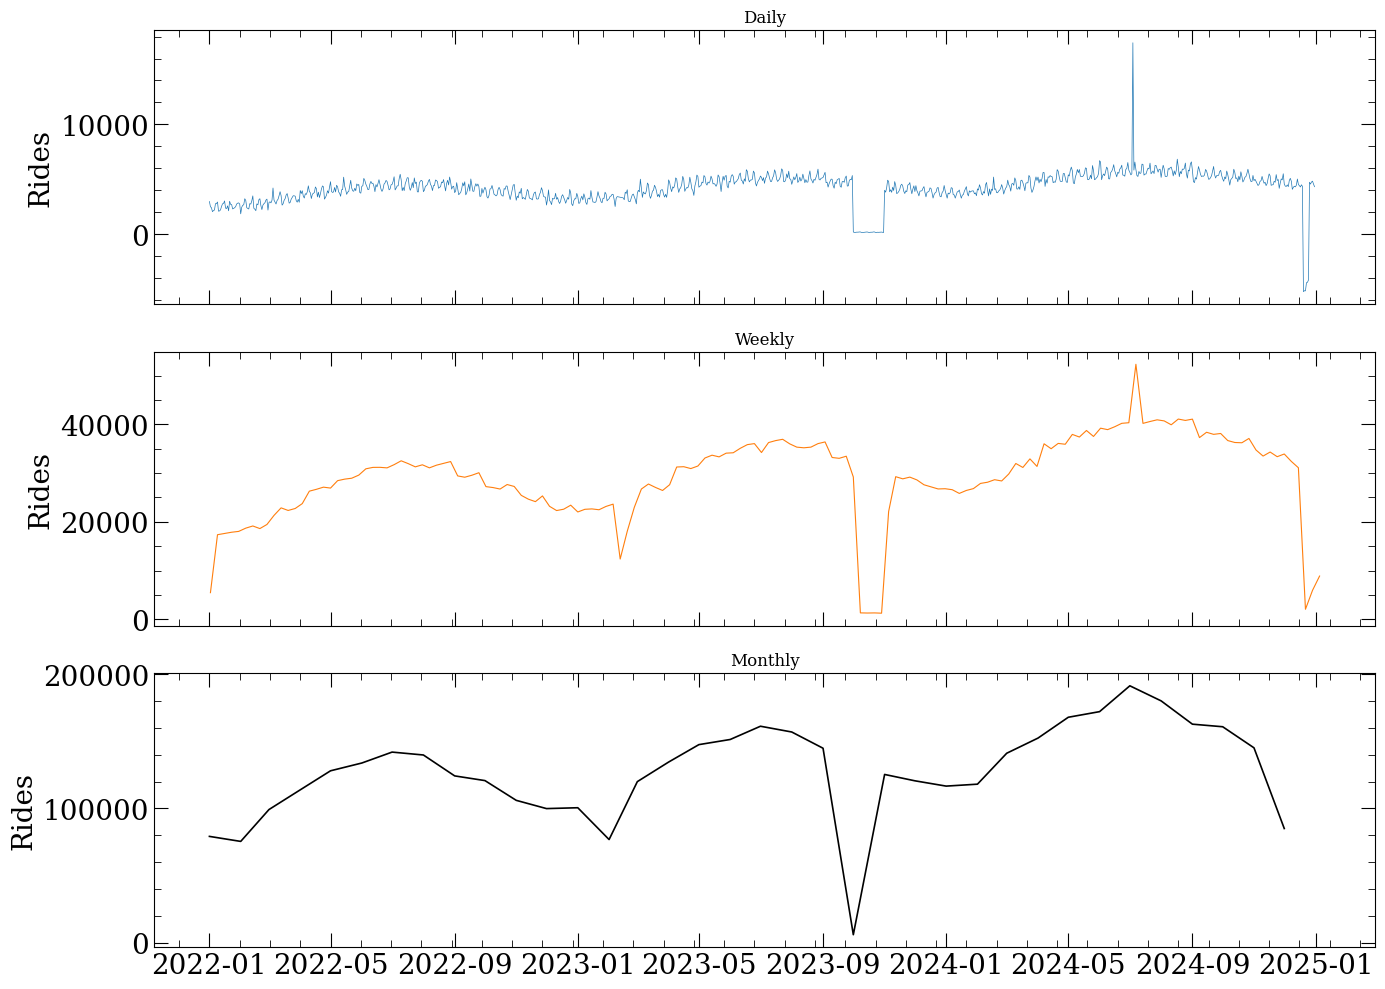

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df.index, df["rides"].values, linewidth=0.5, color="tab:blue")
axes[0].set_ylabel("Rides")
axes[0].set_title("Daily")
axes[1].plot(weekly.index, weekly.values, linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("Rides")
axes[1].set_title("Weekly")
axes[2].plot(monthly.index, monthly.values, linewidth=1.2, color="black")
axes[2].set_ylabel("Rides")
axes[2].set_title("Monthly")
plt.tight_layout()
plt.show()